<a href="https://colab.research.google.com/github/steffiprog/ML/blob/main/7_CNN/normalization_learning_validation_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Загрузка датасета

In [2]:
import pandas as pd

df = pd.read_excel('/content/markup_dataset.xlsx')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   record      0 non-null      float64
 1   id          600 non-null    int64  
 2   title       600 non-null    object 
 3   tags        600 non-null    object 
 4   text        599 non-null    object 
 5   url         600 non-null    object 
 6   difficulty  600 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 32.9+ KB


,record,id,title,tags,text,url,difficulty
0,NaN,0,raFTI: как сопоставлять «хаотичные» названия вин,"Поисковые технологии, Машинное обучение, Data ...","Привет, я Вит Глинка, backend программист в ко...",https://habr.com/ru/articles/1045903/,2
1,NaN,1,Внедрение ИИ-агента глазами QA: полгода от ске...,"Блог компании SENSE, Машинное обучение, Програ...","Привет, Хабр. Меня зовут Егор, я QA Fullstack ...",https://habr.com/ru/companies/it_sense/article...,1
2,NaN,2,Курсы по промптингу? Почитайте детям сказку на...,"Машинное обучение, Читальный зал, Блог компани...","Привет, Хабр! За время написания нескольких кн...",https://habr.com/ru/companies/ru_mts/articles/...,0
3,NaN,3,Дообучаем FLUX.2 [klein] за час на одной видео...,"Блог компании OTUS, Машинное обучение, Искусст...","FLUX.2 [klein] достаточно компактна, чтобы доо...",https://habr.com/ru/companies/otus/articles/10...,2
4,NaN,4,Архиватор рождённый из теории предельного сжат...,"Физика, Сжатие данных, Машинное обучение, Алго...","\n\n## Как всё начиналось\n\n\nВ 1996 году, во...",https://habr.com/ru/articles/1046081/,2


## 2. Предобработка

В моем примере:

0. много лишних столбцов (мне нужны только text и difficulty)

1. могут быть пропуски данных (мы всегда чистим их на всякий случай)

2. где-то при разметке модель сгаллюцинировала и вставила польские слова вместо русских, нам нужно убрать тексты, где таких галлюцинаций много

In [7]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split

def clean_and_prepare_data(file_path):
    # Загрузка Excel-файла
    df = pd.read_excel(file_path)

    # Выбор столбцов 'text' и 'difficulty'
    if 'text' not in df.columns or 'difficulty' not in df.columns:
        print("Error: 'text' or 'difficulty' columns not found in the Excel file.")
        return pd.DataFrame()

    df = df[['text', 'difficulty']]

    # Удаление строк с пропусками
    df = df.dropna(subset=['text', 'difficulty'])
    df = df[df['text'].astype(str).str.strip() != '']

    def preprocess_text(text):
        if not isinstance(text, str):
            return ""

        # Очистка текста
        text = re.sub(r'\s+', ' ', text).strip()

        cyrillic_chars = len(re.findall(r'[а-яА-ЯёЁ]', text))
        latin_chars = len(re.findall(r'[a-zA-Z]', text))

        total_letters = cyrillic_chars + latin_chars
        if total_letters == 0:
            return ""

        # Удаление текстов с менее чем 50% кириллицы
        if (cyrillic_chars / total_letters) < 0.50:
            return ""

        return text

    # Фильтрация текстов по содержанию кириллицы
    df['text'] = df['text'].apply(preprocess_text)

    # Удаление пустых текстов
    df = df[df['text'].astype(str).str.strip() != '']

    # Приведение 'difficulty' к типу int
    df['difficulty'] = df['difficulty'].astype(int)

    print(f"Размер датасета после очистки и фильтрации: {len(df)} строк.")
    return df

def split_dataset(df):
    if df.empty:
        print("DataFrame is empty, skipping dataset splitting.")
        return

    # Разделение данных на обучающую, валидационную и тестовую выборки (70/15/15)
    train_df, rest_df = train_test_split(
        df,
        test_size=0.30,
        random_state=42,
        stratify=df['difficulty']
    )

    val_df, test_df = train_test_split(
        rest_df,
        test_size=0.50,
        random_state=42,
        stratify=rest_df['difficulty']
    )

    print(f"Размеры выборок:")
    print(f" - Обучающая (Train): {len(train_df)}")
    print(f" - Валидационная (Val): {len(val_df)}")
    print(f" - Тестовая (Test): {len(test_df)}")

    # Сохранение выборок в CSV
    train_df.to_csv('train.csv', index=False, encoding='utf-8')
    val_df.to_csv('val.csv', index=False, encoding='utf-8')
    test_df.to_csv('test.csv', index=False, encoding='utf-8')
    print("Файлы train.csv, val.csv, test.csv успешно сохранены!")

if __name__ == "__main__":
    cleaned_df = clean_and_prepare_data('/content/markup_dataset.xlsx')
    split_dataset(cleaned_df)

Размер датасета после очистки и фильтрации: 510 строк.
Размеры выборок:
 - Обучающая (Train): 357
 - Валидационная (Val): 76
 - Тестовая (Test): 77
Файлы train.csv, val.csv, test.csv успешно сохранены!


## 3. Создаём матрицы признаков

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from collections import Counter

# Загружаем обучающие данные
train_df = pd.read_csv('train.csv')

# Токенизация и создание словаря
tokenized_texts = [text.lower().split() for text in train_df['text'].astype(str)]

word_counts = Counter()
for tokens in tokenized_texts:
    word_counts.update(tokens)

special_tokens = ['<pad>', '<unk>']
word_to_idx = {special_tokens[0]: 0, special_tokens[1]: 1}
idx_counter = 2

for word, count in sorted(word_counts.items(), key=lambda item: item[1], reverse=True):
    if word not in word_to_idx:
        word_to_idx[word] = idx_counter
        idx_counter += 1

pad_idx = word_to_idx['<pad>']
unk_idx = word_to_idx['<unk>']
vocab_size = len(word_to_idx)

# Определяем максимальную длину последовательности для заполнения
max_seq_len = max(len(tokens) for tokens in tokenized_texts) if tokenized_texts else 0

# Преобразуем токены в индексы и заполняем/обрезаем последовательности
indexed_texts = []
for tokens in tokenized_texts:
    indexed_sequence = [word_to_idx.get(token, unk_idx) for token in tokens]
    if len(indexed_sequence) < max_seq_len:
        indexed_sequence.extend([pad_idx] * (max_seq_len - len(indexed_sequence)))
    else:
        indexed_sequence = indexed_sequence[:max_seq_len]
    indexed_texts.append(indexed_sequence)

X = torch.tensor(indexed_texts, dtype=torch.long)

print(f"Размер словаря: {vocab_size}")
print(f"Максимальная длина последовательности: {max_seq_len}")
print(f"Форма X (токенизированные и заполненные индексы): {X.shape}")


class HabrTextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, n_filters=128, kernel_sizes=[3, 4, 5], output_dim=3, dropout=0.5, pad_idx=0):
        super().__init__()

        # Слой встраивания: преобразует индексы слов в плотные векторы
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Сверточные слои: список Conv1d слоев с различными размерами ядер
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,  # Входные каналы
                      out_channels=n_filters,     # Выходные каналы
                      kernel_size=ks)             # Размер ядра
            for ks in kernel_sizes
        ])

        # Полносвязный слой: отображает конкатенированные признаки в выходные классы
        self.fc = nn.Linear(len(kernel_sizes) * n_filters, output_dim)
        # Слой Dropout для регуляризации
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)

        # Переставляем измерения для Conv1d
        embedded = embedded.permute(0, 2, 1)

        # Применяем свертки и активацию ReLU
        conved = [F.relu(conv(embedded)) for conv in self.convs]

        # Применяем глобальный макс-пулинг по измерению последовательности
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]

        # Конкатенируем выходы из всех сверточных слоев
        cat = self.dropout(torch.cat(pooled, dim=1))

        # Пропускаем через полносвязный слой
        return self.fc(cat)

Размер словаря: 15982
Максимальная длина последовательности: 136
Форма X (токенизированные и заполненные индексы): torch.Size([357, 136])


In [9]:
X[0] # так выглядит одна строка данных (один текст) после векторизации

tensor([  64,   90,   47,   78, 4332, 4333,   11, 1454, 4334,    3, 4335,  668,
          20,  829, 4336,  830,    5, 1455, 4337,    3,   51,  122, 2249, 4338,
         101,   11,  213, 1456,   31,  102,  297, 4339, 1070,   10,  298,  335,
         430, 1457, 4340, 4341,    6, 4342,    2,    9,   44,    8, 1458,   13,
         336, 4343,    4,  557,   79, 1459,  299, 4344,   21,   11, 4345, 1071,
           9,  300,  496,  558, 4346,   18,  669, 2250,  214, 1460, 4347,  337,
        2250,   95,   58, 4348,   59, 2251, 1461, 2252, 4349, 2253,    2, 4350,
         101, 1462,  830,   19,   58, 2254, 2255,    3, 2256, 4351,  135,   23,
        2257, 4352, 4353,    7,   32, 2258, 4354, 4355,   21,    2, 2259,    3,
         250,    6, 4356,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

In [10]:
X.shape

torch.Size([357, 136])

Векторизуем метки

In [11]:
import pandas as pd

# Load the training data again for labels
train_df = pd.read_csv('train.csv')

y = train_df['difficulty'].values
print(y)

[0 1 0 1 1 2 2 1 2 0 2 1 1 2 0 1 2 1 2 2 2 0 1 2 2 2 0 2 1 1 2 1 2 0 0 0 1
 0 2 0 2 2 2 2 2 2 2 2 1 0 1 2 1 2 2 0 2 1 0 2 1 1 1 0 2 2 1 2 2 0 2 1 2 2
 2 1 2 2 2 0 2 2 2 2 1 1 1 1 0 0 1 2 0 1 1 0 2 1 0 2 1 0 1 1 1 2 0 2 2 1 2
 2 0 1 1 0 0 1 2 2 2 0 0 0 0 2 1 0 0 1 0 2 0 2 2 2 2 0 0 1 2 2 0 0 0 0 0 0
 0 0 2 0 1 0 1 2 2 0 2 0 2 1 2 0 2 2 0 2 1 2 2 1 0 1 0 0 2 2 2 2 2 0 2 1 2
 1 0 2 2 1 2 0 1 0 2 2 2 1 0 0 1 2 1 0 1 2 1 1 0 1 0 2 2 1 2 2 2 1 1 1 1 0
 1 1 1 2 0 1 1 0 2 2 1 0 1 2 1 0 2 2 2 1 1 1 2 2 2 1 0 1 1 1 1 2 1 2 0 1 2
 1 1 1 0 0 1 2 1 2 1 1 0 2 2 0 0 2 2 1 2 2 2 1 1 1 2 1 0 1 1 0 0 2 2 0 0 2
 0 1 0 2 1 2 2 0 2 0 2 0 1 2 0 0 2 2 2 2 0 1 2 0 2 1 1 1 0 0 0 1 2 1 1 2 2
 2 0 1 2 1 1 1 2 0 2 0 2 2 0 2 2 2 0 0 2 0 0 2 1]


Векторизуйте вашу таблицу. Рекомендую вывести на экран небольшой срез получившейся матрицы, а также посмотреть shape, чтобы убедиться, что данные обработались корректно

In [15]:
print("Срез первой строки данных (X[0]):")
print(X[0])
print("\nФорма векторизованных данных (X.shape):")
print(X.shape)

Срез первой строки данных (X[0]):
tensor([  64,   90,   47,   78, 4332, 4333,   11, 1454, 4334,    3, 4335,  668,
          20,  829, 4336,  830,    5, 1455, 4337,    3,   51,  122, 2249, 4338,
         101,   11,  213, 1456,   31,  102,  297, 4339, 1070,   10,  298,  335,
         430, 1457, 4340, 4341,    6, 4342,    2,    9,   44,    8, 1458,   13,
         336, 4343,    4,  557,   79, 1459,  299, 4344,   21,   11, 4345, 1071,
           9,  300,  496,  558, 4346,   18,  669, 2250,  214, 1460, 4347,  337,
        2250,   95,   58, 4348,   59, 2251, 1461, 2252, 4349, 2253,    2, 4350,
         101, 1462,  830,   19,   58, 2254, 2255,    3, 2256, 4351,  135,   23,
        2257, 4352, 4353,    7,   32, 2258, 4354, 4355,   21,    2, 2259,    3,
         250,    6, 4356,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

Форма векторизованных данных (X.shape):
torch.Size([

Изучите документацию TfIdfVectorizer; что делает параметр max_features, когда его лучше использовать? Векторизуйте X еще раз с использованием этого параметра. Какое значение вы ввели?

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

train_df = pd.read_csv('train.csv')

# Я выбрала 5000 как разумное начальное значение для max_features,
# чтобы ограничить размерность, но сохранить достаточно информации.
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Векторизация текстов
X_tfidf = tfidf_vectorizer.fit_transform(train_df['text'])

print(f"Использованное значение max_features: {tfidf_vectorizer.max_features}")
print("Срез TF-IDF матрицы (первая строка, первые 100 признаков):")
# TfIdfVectorizer возвращает разреженную матрицу, поэтому преобразуем в плотный формат для среза
print(X_tfidf[0, :100].toarray())

print("\nФорма векторизованных данных (X_tfidf.shape):")
print(X_tfidf.shape)

Использованное значение max_features: 5000
Срез TF-IDF матрицы (первая строка, первые 100 признаков):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]]

Форма векторизованных данных (X_tfidf.shape):
(357, 5000)


In [31]:
import torch
import pandas as pd

# X уже является torch.long тензором для обучающих данных
X_train_tensor = X
# y - это массив numpy, преобразуем его в torch.long тензор для обучающих меток
y_train_tensor = torch.tensor(y, dtype=torch.long)

# Загружаем валидационные данные
val_df = pd.read_csv('val.csv')

# Токенизация валидационных текстов, используя тот же подход, что и для обучающих данных
tokenized_val_texts = [text.lower().split() for text in val_df['text'].astype(str)]

# Преобразуем токены в индексы, используя словарь (word_to_idx), созданный на обучающих данных
indexed_val_texts = []
for tokens in tokenized_val_texts:
    indexed_sequence = [word_to_idx.get(token, unk_idx) for token in tokens]
    # Дополняем или обрезаем последовательности до той же максимальной длины (max_seq_len),
    # что и для обучающих данных
    if len(indexed_sequence) < max_seq_len:
        indexed_sequence.extend([pad_idx] * (max_seq_len - len(indexed_sequence)))
    else:
        indexed_sequence = indexed_sequence[:max_seq_len]
    indexed_val_texts.append(indexed_sequence)

# Создаем тензоры для валидационных данных и меток
X_val_tensor = torch.tensor(indexed_val_texts, dtype=torch.long)
y_val_tensor = torch.tensor(val_df['difficulty'].values, dtype=torch.long)

print(f"Форма X_train_tensor: {X_train_tensor.shape}")
print(f"Форма y_train_tensor: {y_train_tensor.shape}")
print(f"Форма X_val_tensor: {X_val_tensor.shape}")
print(f"Форма y_val_tensor: {y_val_tensor.shape}")

Форма X_train_tensor: torch.Size([357, 136])
Форма y_train_tensor: torch.Size([357])
Форма X_val_tensor: torch.Size([76, 136])
Форма y_val_tensor: torch.Size([76])


In [32]:
X_tensor[0], y_tensor[0]

(tensor([  64,   90,   47,   78, 4332, 4333,   11, 1454, 4334,    3, 4335,  668,
           20,  829, 4336,  830,    5, 1455, 4337,    3,   51,  122, 2249, 4338,
          101,   11,  213, 1456,   31,  102,  297, 4339, 1070,   10,  298,  335,
          430, 1457, 4340, 4341,    6, 4342,    2,    9,   44,    8, 1458,   13,
          336, 4343,    4,  557,   79, 1459,  299, 4344,   21,   11, 4345, 1071,
            9,  300,  496,  558, 4346,   18,  669, 2250,  214, 1460, 4347,  337,
         2250,   95,   58, 4348,   59, 2251, 1461, 2252, 4349, 2253,    2, 4350,
          101, 1462,  830,   19,   58, 2254, 2255,    3, 2256, 4351,  135,   23,
         2257, 4352, 4353,    7,   32, 2258, 4354, 4355,   21,    2, 2259,    3,
          250,    6, 4356,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]),
 tensor(0))

## 4. Оборачиваем в датасет

Здесь мы создаём специальный объект для пакетной обработки

In [33]:
from torch.utils.data import DataLoader, TensorDataset

dataset_torch = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset_torch, batch_size=32, shuffle=True)

In [34]:
dataset_torch # контейнер данных

In [35]:
dataloader # итератор: он оборачивает Dataset и добавляет batching, shuffling, parallel loading

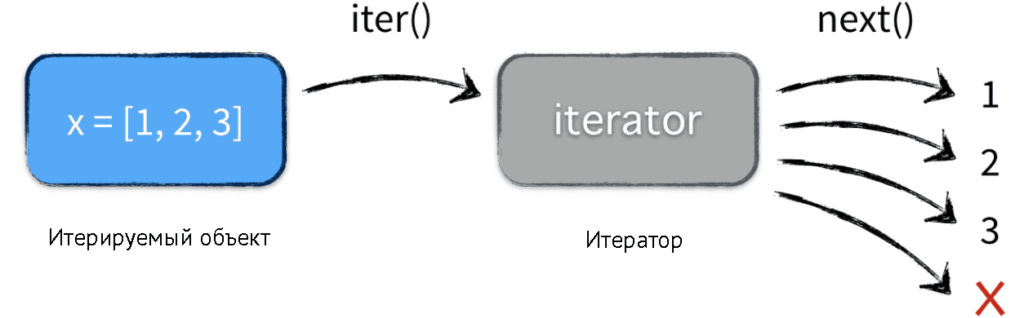

Создайте дата-лоадер для своих данных

In [36]:
from torch.utils.data import DataLoader, TensorDataset

# Создаем TensorDataset для обучающего и валидационного наборов данных
dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
dataset_val = TensorDataset(X_val_tensor, y_val_tensor)

# Создаем DataLoaders
train_dataloader = DataLoader(dataset_train, batch_size=32, shuffle=True)
val_dataloader = DataLoader(dataset_val, batch_size=32, shuffle=False) # Без перемешивания для валидации

print("Train DataLoader и Validation DataLoader успешно созданы.")

Train DataLoader и Validation DataLoader успешно созданы.


## 6. Обучение

In [44]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Создаем экземпляр модели HabrTextCNN
model = HabrTextCNN(vocab_size, embedding_dim=300, output_dim=3, dropout=0.5, pad_idx=pad_idx).to(device)

# Определяем функцию потерь, оптимизатор и планировщик скорости обучения
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 7

print("Начинаем обучение...")
for epoch in range(num_epochs):
    model.train() # Устанавливаем модель в режим обучения
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_dataloader:
        # Перемещаем данные на соответствующее устройство
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()

    avg_train_loss = total_loss / len(train_dataloader)
    train_accuracy = 100. * correct / total

    # Фаза валидации
    model.eval() # Устанавливаем модель в режим оценки
    val_total_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad(): # Отключаем вычисление градиентов на валидации
        for batch_x_val, batch_y_val in val_dataloader:
            batch_x_val, batch_y_val = batch_x_val.to(device), batch_y_val.to(device)
            val_outputs = model(batch_x_val)
            val_loss = criterion(val_outputs, batch_y_val)

            val_total_loss += val_loss.item()
            _, val_predicted = val_outputs.max(1)
            val_total += batch_y_val.size(0)
            val_correct += val_predicted.eq(batch_y_val).sum().item()

    avg_val_loss = val_total_loss / len(val_dataloader)
    val_accuracy = 100. * val_correct / val_total

    scheduler.step(avg_val_loss) # Адаптивное уменьшение скорости обучения по валидационной потере

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

print("Обучение завершено!")

Using device: cpu
Начинаем обучение...
Epoch 1/7, Train Loss: 1.4361, Train Acc: 32.49%, Val Loss: 1.1586, Val Acc: 40.79%
Epoch 2/7, Train Loss: 1.0003, Train Acc: 53.78%, Val Loss: 1.0910, Val Acc: 32.89%
Epoch 3/7, Train Loss: 0.7210, Train Acc: 68.63%, Val Loss: 1.0960, Val Acc: 40.79%
Epoch 4/7, Train Loss: 0.5706, Train Acc: 79.27%, Val Loss: 1.0905, Val Acc: 31.58%
Epoch 5/7, Train Loss: 0.4459, Train Acc: 85.15%, Val Loss: 1.1235, Val Acc: 40.79%
Epoch 6/7, Train Loss: 0.3379, Train Acc: 90.76%, Val Loss: 1.0892, Val Acc: 35.53%
Epoch 7/7, Train Loss: 0.2990, Train Acc: 91.60%, Val Loss: 1.1206, Val Acc: 42.11%
Обучение завершено!


## 7. Получаем предсказания

In [45]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import torch

# Загрузка тестовых данных
test_df = pd.read_csv('test.csv')

# Используем тот же словарь (word_to_idx, pad_idx, unk_idx, max_seq_len), что и для обучающих данных
tokenized_test_texts = [text.lower().split() for text in test_df['text'].astype(str)]

indexed_test_texts = []
for tokens in tokenized_test_texts:
    indexed_sequence = [word_to_idx.get(token, unk_idx) for token in tokens]
    # Дополняем или обрезаем до той же максимальной длины последовательности, что и обучающие данные
    if len(indexed_sequence) < max_seq_len:
        indexed_sequence.extend([pad_idx] * (max_seq_len - len(indexed_sequence)))
    else:
        indexed_sequence = indexed_sequence[:max_seq_len]
    indexed_test_texts.append(indexed_sequence)

X_test_tensor = torch.tensor(indexed_test_texts, dtype=torch.long)
y_test_tensor = torch.tensor(test_df['difficulty'].values, dtype=torch.long)

# Перемещаем тестовые тензоры на соответствующее устройство
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

# Создаем DataLoader для тестового набора
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Без перемешивания для оценки

print("Начинаем оценку на тестовом наборе...")
model.eval() # Переводим модель в режим оценки
y_true_all = []
y_pred_all = []

with torch.no_grad(): # Отключаем вычисление градиентов во время инференса
    for batch_x_test, batch_y_test in test_dataloader:
        outputs = model(batch_x_test)
        _, predicted = torch.max(outputs, 1)
        y_true_all.extend(batch_y_test.cpu().numpy())
        y_pred_all.extend(predicted.cpu().numpy())

print("Оценка завершена!")

Начинаем оценку на тестовом наборе...
Оценка завершена!


In [42]:
print("Classification Report on Test Set:")
print(classification_report(y_true_all, y_pred_all))

print("Confusion Matrix on Test Set:")
print(confusion_matrix(y_true_all, y_pred_all))

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.10      0.17        21
           1       0.26      0.25      0.26        24
           2       0.50      0.81      0.62        32

    accuracy                           0.44        77
   macro avg       0.59      0.39      0.35        77
weighted avg       0.56      0.44      0.38        77

Confusion Matrix on Test Set:
[[ 2 11  8]
 [ 0  6 18]
 [ 0  6 26]]


## Анализ результатов обучения

### Что получилось хорошо:

*   **Быстрое обучение на тренировочных данных**: Модель демонстрирует быстрый рост точности на train выборке, достигая более 90% к концу 7 эпох.
*   **Снижение Train Loss**: на обучающей выборке стабильно снижается на протяжении всего обучения, что подтверждает успешное освоение набора.

### Что можно улучшить:

*   **Низкая обобщающая способность**: Несмотря на высокую точность на тренировочных данных, точность на валидационной выборке остается низкой (около 42%) и не улучшается существенно. Это является явным признаком **переобучения**.
*   **Низкая общая точность на тестовых данных**: Итоговая точность на тестовом наборе составляет всего 44%, что является неудовлетворительным результатом для многоклассовой классификации.
*   **Проблемы с классификацией классов 0 и 1**: Classification Report показывает низкую точность (precision) и полноту (recall) для классов 0 ( 0.10 recall) и 1 (0.26 precision, 0.25 recall). Модель почти не распознает объекты этих классов.
*   **Доминирование класса 2**: Confusion Matrix показывает, что модель склонна предсказывать класс 2 для большинства примеров. Из 77 тестовых примеров, 26 были правильно классифицированы как класс 2, но и значительное количество примеров из классов 0 (8) и 1 (18) были ошибочно отнесены к классу 2. Это может указывать на то, что модель нашла простой способ минимизировать ошибку, всегда предсказывая наиболее распространенный класс.

### Рекомендации для улучшения:

1.  **Сбалансированность классов**: Проверить распределение классов в обучающей, валидационной и тестовой выборках. Если классы несбалансированы, можно применить техники, такие как взвешивание классов в функции потерь (`CrossEntropyLoss(weight=...)`), оверсэмплинг минорных классов (например, SMOTE) или андерсэмплинг мажорных классов.
2.  **Гиперпараметры**:
    *   **Уменьшить dropout**: Текущий dropout 0.5 может быть слишком высоким, что способствует переобучению, особенно при такой маленькой выборке. Попробуйте значения 0.2-0.4.
    *   **Регулировка learning rate и weight decay**: Можно попробовать более агрессивное снижение `lr` или другую стратегию `ReduceLROnPlateau`, а также поэкспериментировать с `weight_decay`.
    *   **Увеличить количество эпох**: Несмотря на переобучение, возможно, стоит дать модели больше эпох для обучения после настройки других гиперпараметров, чтобы убедиться, что она достаточно сходится.
3.  **Улучшение предобработки текста**:
    *   **Добавить лемматизацию/стемминг**: Приведение слов к их базовой форме может уменьшить размер словаря и улучшить обобщающую способность.
    *   **Использование предварительно обученных эмбеддингов**: Word2Vec, FastText, BERT или другие эмбеддинги, предварительно обученные на большом корпусе русского языка, могут значительно улучшить качество представления текста, особенно при небольшом размере датасета.
4.  **Анализ данных**: Более глубоко изучить тексты классов 0, 1 и 2. Есть ли какие-то явные различия в их содержимом, которые модель могла бы использовать? Возможно, некоторые классы слишком похожи или слишком мало данных для их различения.
5.  **Архитектура модели**: Хотя текущая TextCNN является хорошей отправной точкой, возможно, для данной задачи потребуется более сложная модель (например, с более глубокой архитектурой или использованием трансформеров), если другие методы не дадут значительного улучшения.

## Финальная итерация с учетом улучшения по сбалансированности классов и гиперпараметрам

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Сбалансированность классов: Расчет весов для CrossEntropyEntropyLoss
# Подсчитываем количество примеров для каждого класса в обучающем наборе
class_counts = Counter(y_train_tensor.cpu().numpy())
# Сортируем классы по индексу для соответствия порядка весов классам
num_classes = len(class_counts)
# Инициализируем массив весов
class_weights = np.zeros(num_classes)
for i in range(num_classes):
    class_weights[i] = class_counts[i]

# Обратная частота: более редкие классы получают больший вес
class_weights = 1. / (class_weights + 1e-5)
# Нормализуем веса
class_weights = class_weights / np.sum(class_weights) * num_classes
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Расчитанные веса классов: {class_weights_tensor}")

# Создаем экземпляр модели HabrTextCNN
# 2. Гиперпараметры: Уменьшаем dropout
model = HabrTextCNN(vocab_size, embedding_dim=300, output_dim=num_classes, dropout=0.4, pad_idx=pad_idx).to(device)

# Определяем функцию потерь с учетом весов классов
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# Оптимизатор и планировщик скорости обучения
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 2. Гиперпараметры: Увеличиваем количество эпох
num_epochs = 15

print("Начинаем обучение (с учетом весов классов, dropout=0.4, эпох=15)...")
for epoch in range(num_epochs):
    model.train() # Переводим модель в режим обучения
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()

    avg_train_loss = total_loss / len(train_dataloader)
    train_accuracy = 100. * correct / total

    # Фаза валидации
    model.eval() # Переводим модель в режим оценки
    val_total_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad(): # Отключаем вычисление градиентов для валидации
        for batch_x_val, batch_y_val in val_dataloader:
            batch_x_val, batch_y_val = batch_x_val.to(device), batch_y_val.to(device)
            val_outputs = model(batch_x_val)
            val_loss = criterion(val_outputs, batch_y_val)

            val_total_loss += val_loss.item()
            _, val_predicted = val_outputs.max(1)
            val_total += batch_y_val.size(0)
            val_correct += val_predicted.eq(batch_y_val).sum().item()

    avg_val_loss = val_total_loss / len(val_dataloader)
    val_accuracy = 100. * val_correct / val_total

    scheduler.step(avg_val_loss) # Адаптивное уменьшение скорости обучения на основе валидационных потерь

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

print("Обучение завершено!")

# После обучения перезапустите ячейки для получения предсказаний и отчета по мере необходимости.

Using device: cpu
Расчитанные веса классов: tensor([1.1602, 1.0452, 0.7946])
Начинаем обучение (с учетом весов классов, dropout=0.4, эпох=15)...
Epoch 1/15, Train Loss: 1.2185, Train Acc: 35.29%, Val Loss: 1.0923, Val Acc: 36.84%
Epoch 2/15, Train Loss: 0.7801, Train Acc: 66.39%, Val Loss: 1.1364, Val Acc: 27.63%
Epoch 3/15, Train Loss: 0.5740, Train Acc: 82.63%, Val Loss: 1.0894, Val Acc: 40.79%
Epoch 4/15, Train Loss: 0.4215, Train Acc: 89.36%, Val Loss: 1.0855, Val Acc: 38.16%
Epoch 5/15, Train Loss: 0.2890, Train Acc: 92.72%, Val Loss: 1.1087, Val Acc: 40.79%
Epoch 6/15, Train Loss: 0.2425, Train Acc: 96.92%, Val Loss: 1.1128, Val Acc: 40.79%
Epoch 7/15, Train Loss: 0.1927, Train Acc: 96.64%, Val Loss: 1.1052, Val Acc: 43.42%
Epoch 8/15, Train Loss: 0.1692, Train Acc: 98.32%, Val Loss: 1.0897, Val Acc: 44.74%
Epoch 9/15, Train Loss: 0.1242, Train Acc: 100.00%, Val Loss: 1.1032, Val Acc: 42.11%
Epoch 10/15, Train Loss: 0.1145, Train Acc: 98.60%, Val Loss: 1.1212, Val Acc: 44.74%
Epo

In [50]:
# Предсказания

# Загрузка тестовых данных
test_df = pd.read_csv('test.csv')

# Используем тот же словарь (word_to_idx, pad_idx, unk_idx, max_seq_len), что и для обучающих данных
tokenized_test_texts = [text.lower().split() for text in test_df['text'].astype(str)]

indexed_test_texts = []
for tokens in tokenized_test_texts:
    indexed_sequence = [word_to_idx.get(token, unk_idx) for token in tokens]
    # Дополняем или обрезаем до той же максимальной длины последовательности, что и обучающие данные
    if len(indexed_sequence) < max_seq_len:
        indexed_sequence.extend([pad_idx] * (max_seq_len - len(indexed_sequence)))
    else:
        indexed_sequence = indexed_sequence[:max_seq_len]
    indexed_test_texts.append(indexed_sequence)

X_test_tensor = torch.tensor(indexed_test_texts, dtype=torch.long)
y_test_tensor = torch.tensor(test_df['difficulty'].values, dtype=torch.long)

# Перемещаем тестовые тензоры на соответствующее устройство
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

# Создаем DataLoader для тестового набора
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Без перемешивания для оценки

print("Начинаем оценку на тестовом наборе...")
model.eval() # Переводим модель в режим оценки
y_true_all = []
y_pred_all = []

with torch.no_grad(): # Отключаем вычисление градиентов во время инференса
    for batch_x_test, batch_y_test in test_dataloader:
        outputs = model(batch_x_test)
        _, predicted = torch.max(outputs, 1)
        y_true_all.extend(batch_y_test.cpu().numpy())
        y_pred_all.extend(predicted.cpu().numpy())

print("Оценка завершена!")

Начинаем оценку на тестовом наборе...
Оценка завершена!


In [52]:
print("Classification Report on Test Set:")
print(classification_report(y_true_all, y_pred_all))

print("Confusion Matrix on Test Set:")
print(confusion_matrix(y_true_all, y_pred_all))

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.44      0.33      0.38        21
           1       0.00      0.00      0.00        24
           2       0.52      0.91      0.66        32

    accuracy                           0.47        77
   macro avg       0.32      0.41      0.35        77
weighted avg       0.33      0.47      0.38        77

Confusion Matrix on Test Set:
[[ 7  4 10]
 [ 7  0 17]
 [ 2  1 29]]


## Интерпретация

После последних изменений в обучении (веса классов, dropout, эпохи) наблюдаются смешанные результаты:

**Общая точность:** Незначительно улучшилась с 44% до 47%.

**Оверфиттинг:** По-прежнему сильный. Точность на обучении достигает 100%, в то время как на валидации и тесте остается низкой (~42-44%), что указывает на то, что модель плохо обобщает.

**Класс 0:** Заметно улучшилась полнота (recall) и F1-мера (с 0.17 до 0.38), теперь модель лучше находит примеры этого класса.
**Класс 1:** Производительность полностью обвалилась. Precision и recall упали до 0.00 (было 0.26 и 0.25). Модель теперь вообще не распознает этот класс, ошибочно классифицируя все его примеры как класс 0 или 2.
**Класс 2:** Продолжает быть наиболее хорошо предсказуемым, с улучшением recall (до 0.91) и F1-меры (до 0.66).

**Вывод:** Изменения помогли улучшить распознавание класса 0 и 2, но катастрофически ухудшили предсказание класса 1. Текущая стратегия балансировки классов либо слишком агрессивна, либо не подходит для класса 1, который теперь полностью игнорируется моделью. Следующие шаги должны быть направлены на более глубокий анализ класса 1 и уточнение методов обработки несбалансированных данных.